In [1]:
import netket as nk

print("NetKet version:", nk.__version__)

NetKet version: 3.18


/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
L = 4  # Side of the square
graph = nk.graph.Square(L)
N = graph.n_nodes
N_f = 5
hi = nk.hilbert.SpinOrbitalFermions(N, s=None, n_fermions=N_f)
from netket.operator.fermion import destroy as c
from netket.operator.fermion import create as cdag
from netket.operator.fermion import number as nc
from netket.experimental.operator import ParticleNumberConservingFermioperator2nd
t = 1.0
V = 4.0

H = 0.0
for i, j in graph.edges():
    H -= t * (cdag(hi, i) * c(hi, j) + cdag(hi, j) * c(hi, i))
    H += V * nc(hi, i) * nc(hi, j)
    H_pnc = ParticleNumberConservingFermioperator2nd.from_fermionoperator2nd(H)

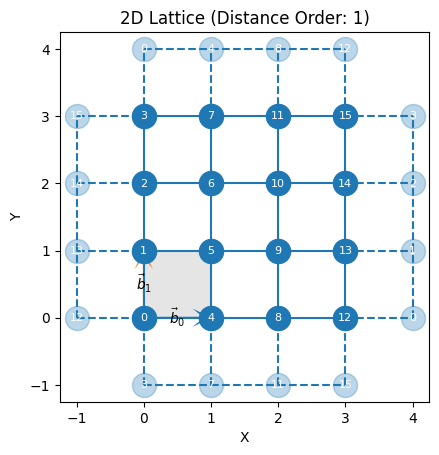

<Axes: title={'center': '2D Lattice (Distance Order: 1)'}, xlabel='X', ylabel='Y'>

In [22]:
graph.draw()

In [3]:
H

FermionOperator2nd(hilbert=SpinOrbitalFermions(n_orbitals=16, n_fermions=5), n_operators=96, dtype=float64)

In [4]:
H_pnc

ParticleNumberConservingFermioperator2nd(_hilbert=SpinOrbitalFermions(n_orbitals=16, n_fermions=5), _operator_data={'diag': {4: (None, None, COOArray(_coords=Array([[ 1,  0],
       [ 2,  1],
       [ 3,  0],
       [ 3,  2],
       [ 4,  0],
       [ 5,  1],
       [ 5,  4],
       [ 6,  2],
       [ 6,  5],
       [ 7,  3],
       [ 7,  4],
       [ 7,  6],
       [ 8,  4],
       [ 9,  5],
       [ 9,  8],
       [10,  6],
       [10,  9],
       [11,  7],
       [11,  8],
       [11, 10],
       [12,  0],
       [12,  8],
       [13,  1],
       [13,  9],
       [13, 12],
       [14,  2],
       [14, 10],
       [14, 13],
       [15,  3],
       [15, 11],
       [15, 12],
       [15, 14]], dtype=int32), data=Array([-4., -4., -4., -4., -4., -4., -4., -4., -4., -4., -4., -4., -4.,
       -4., -4., -4., -4., -4., -4., -4., -4., -4., -4., -4., -4., -4.,
       -4., -4., -4., -4., -4., -4.], dtype=float64), shape=(16, 16), fill_value=0))}, 'offdiag': {2: (COOArray(_coords=Array([[ 0],
 

In [5]:
# Convert the Hamiltonian to a sparse matrix
sp_h = H.to_sparse()
from scipy.sparse.linalg import eigsh

eig_vals, eig_vecs = eigsh(sp_h, k=2, which="SA")

E_gs = eig_vals[0]

print("Exact ground state energy:", E_gs)

Exact ground state energy: -6.859013554319585


In [6]:
import jax
import jax.numpy as jnp


# Note: This function can also be found inside of netket, in `nk.jax.logdet_cmplx`, but we implement it here
# for pedagogical purposes.
def _logdet_cmplx(A):
    sign, logabsdet = jnp.linalg.slogdet(A)
    return logabsdet.astype(complex) + jnp.log(sign.astype(complex))

In [7]:
from flax import nnx
from netket.nn.masked_linear import default_kernel_init
from typing import Any
from functools import partial

DType = Any


class LogSlaterDeterminant(nnx.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions

    def __init__(
        self,
        hilbert,
        kernel_init=default_kernel_init,
        param_dtype=float,
        *,
        rngs: nnx.Rngs,
    ):
        self.hilbert = hilbert

        # To generate random numbers we need to extract the key from the `rngs` object.
        key = rngs.params()

        # the N x Nf matrix of the orbitals
        self.M = nnx.Param(
            kernel_init(
                key,
                (
                    self.hilbert.n_orbitals,
                    self.hilbert.n_fermions,
                ),
                param_dtype,
            )
        )

    def __call__(self, n: jax.Array) -> jax.Array:
        # For simplicity, we write a function that operates on a single configuration of size (N,)
        # and we vectorize it using `jnp.vectorize` with the signature='(n)->()' argument, which specifies
        # that the function is defined to operate on arrays of shape (n,) and return scalars.
        @partial(jnp.vectorize, signature="(n)->()")
        def log_sd(n):
            # Find the positions of the occupied orbitals
            R = n.nonzero(size=self.hilbert.n_fermions)[0]

            # Extract from the (N, Nf) matrix the (Nf, Nf) submatrix of M corresponding to the occupied orbitals.
            A = self.M[R]

            return _logdet_cmplx(A)

        return log_sd(n)

In [8]:
# Create the Slater determinant model, using the seed 0
model = LogSlaterDeterminant(hi, rngs=nnx.Rngs(0))

# Define the Metropolis-Hastings sampler
sa = nk.sampler.MetropolisFermionHop(hi, graph=graph)

In [9]:
vstate = nk.vqs.MCState(sa, model, n_samples=2**12, n_discard_per_chain=16)

In [10]:
# Define the optimizer
op = nk.optimizer.Sgd(learning_rate=0.05)

# Define a preconditioner
preconditioner = nk.optimizer.SR(diag_shift=0.05)

# Create the VMC (Variational Monte Carlo) driver
gs = nk.VMC(H, op, variational_state=vstate, preconditioner=preconditioner)
# Construct the logger to visualize the data later on
slater_log = nk.logging.RuntimeLog()

# Run the optimization for 300 iterations
gs.run(n_iter=300, out=slater_log)

100%|██████████| 300/300 [01:14<00:00,  4.04it/s, Energy=-5.082+0.000j ± 0.035 [σ²=4.570, R̂=1.0021]]


(RuntimeLog():
  keys = ['acceptance', 'Energy'],)

In [11]:
sd_energy = vstate.expect(H)
error = abs((sd_energy.mean - E_gs) / E_gs)

print(f"Optimized energy : {sd_energy}")
print(f"Relative error   : {error}")

Optimized energy : -5.034+0.000j ± 0.036 [σ²=4.479, R̂=1.0038]
Relative error   : 0.2661235040075364


In [12]:
from flax import nnx
from netket.nn.masked_linear import default_kernel_init
from typing import Any

DType = Any


class LogNeuralJastrowSlater(nnx.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions

    def __init__(
        self,
        hilbert,
        jastrow_hidden_units: int,
        kernel_init=default_kernel_init,
        param_dtype=float,
        *,
        rngs: nnx.Rngs,
    ):
        self.hilbert = hilbert

        # To generate random numbers we need to extract the key from the `rngs` object.
        key = rngs.params()

        # the N x Nf matrix of the orbitals
        self.M = nnx.Param(
            kernel_init(
                key,
                (
                    self.hilbert.n_orbitals,
                    self.hilbert.n_fermions,
                ),
                param_dtype,
            )
        )

        # The Neural Jastrow wf
        self.jastrow_linear = nnx.Linear(
            in_features=hilbert.n_orbitals,
            out_features=jastrow_hidden_units,
            param_dtype=param_dtype,
            rngs=rngs,
        )

    def __call__(self, n: jax.Array) -> jax.Array:
        # For simplicity, we write a function that operates on a single configuration of size (N,)
        # and we vectorize it using `jnp.vectorize` with the signature='(n)->()' argument, which specifies
        # that the function is defined to operate on arrays of shape (n,) and return scalars.
        @partial(jnp.vectorize, signature="(n)->()")
        def log_sd(n):
            # Construct the Neural Jastrow
            J = self.jastrow_linear(n)
            J = jax.nn.tanh(J)
            J = J.sum()

            # Construct the slater determinant
            R = n.nonzero(size=self.hilbert.n_fermions)[0]
            # Extract from the (N, Nf) matrix the (Nf, Nf) submatrix of M corresponding to the occupied orbitals.
            A = self.M[R]
            log_slater = _logdet_cmplx(A)

            # Multiply log slater with the jastrow (and since we are working in log space, this becomes a sum)
            return log_slater + J

        return log_sd(n)

In [13]:
# Create a Neural Jastrow Slater wave function
model = LogNeuralJastrowSlater(hi, jastrow_hidden_units=N, rngs=nnx.Rngs(2))

# Define a Metropolis exchange sampler
sa = nk.sampler.MetropolisFermionHop(hi, graph=graph)

# Define an optimizer
op = nk.optimizer.Sgd(learning_rate=0.05)

# Create a variational state
vstate = nk.vqs.MCState(sa, model, n_samples=2**12, n_discard_per_chain=16)

# Create a Variational Monte Carlo driver
preconditioner = nk.optimizer.SR(diag_shift=0.05)
gs = nk.VMC(H, op, variational_state=vstate, preconditioner=preconditioner)

# Construct the logger to visualize the data later on
nj_log = nk.logging.RuntimeLog()

# Run the optimization for 300 iterations
gs.run(n_iter=300, out=nj_log)

100%|██████████| 300/300 [01:39<00:00,  3.03it/s, Energy=-6.826+0.000j ± 0.010 [σ²=0.426, R̂=1.0016]]    


(RuntimeLog():
  keys = ['acceptance', 'Energy'],)

In [14]:
sd_energy = vstate.expect(H)
error = abs((sd_energy.mean - E_gs) / E_gs)

print(f"Optimized energy : {sd_energy}")
print(f"Relative error   : {error}")

Optimized energy : -6.815+0.000j ± 0.011 [σ²=0.467, R̂=1.0022]
Relative error   : 0.006438839864036472


In [15]:
class LogNeuralBackflow(nnx.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions

    def __init__(
        self,
        hilbert,
        hidden_units: int,
        kernel_init=default_kernel_init,
        param_dtype=float,
        *,
        rngs: nnx.Rngs,
    ):
        self.hilbert = hilbert

        # To generate random numbers we need to extract the key from the `rngs` object.
        key = rngs.params()

        # the N x Nf matrix of the orbitals
        self.M = nnx.Param(
            kernel_init(
                key,
                (
                    self.hilbert.n_orbitals,
                    self.hilbert.n_fermions,
                ),
                param_dtype,
            )
        )

        # Construct the Backflow. Takes as input strings of $N$ occupation numbers, outputs an $N x Nf$ matrix
        # that modifies the bare orbitals.
        self.backflow = nnx.Sequential(
            # First layer, input (..., N,) output (..., hidden_units)
            nnx.Linear(
                in_features=hilbert.size,
                out_features=hidden_units,
                param_dtype=param_dtype,
                rngs=rngs,
            ),
            nnx.tanh,
            # Last layer, input (..., hidden_units,) output (..., N x Nf)
            nnx.Linear(
                in_features=hidden_units,
                out_features=hilbert.n_orbitals * hilbert.n_fermions,
                param_dtype=param_dtype,
                rngs=rngs,
            ),
            # Reshape into the orbital shape, (..., N, Nf)
            lambda x: x.reshape(
                x.shape[:-1] + (hilbert.n_orbitals, hilbert.n_fermions)
            ),
        )

    def __call__(self, n: jax.Array) -> jax.Array:
        # For simplicity, we write a function that operates on a single configuration of size (N,)
        # and we vectorize it using `jnp.vectorize` with the signature='(n)->()' argument, which specifies
        # that the function is defined to operate on arrays of shape (n,) and return scalars.
        @partial(jnp.vectorize, signature="(n)->()")
        def log_sd(n):
            # Construct the Backflow. Takes as input strings of $N$ occupation numbers, outputs an $N x Nf$ matrix
            # that modifies the bare orbitals.
            F = self.backflow(n)
            # Add the backflow correction to the bare orbitals
            M = self.M + F

            # Find the positions of the occupied, backflow-modified orbitals
            R = n.nonzero(size=self.hilbert.n_fermions)[0]
            A = M[R]
            return _logdet_cmplx(A)

        return log_sd(n)

In [16]:
# Create a neural backflow wave function
model = LogNeuralBackflow(hi, hidden_units=N, rngs=nnx.Rngs(3))

# Define a Metropolis exchange sampler
sa = nk.sampler.MetropolisFermionHop(hi, graph=graph)

# Define an optimizer
op = nk.optimizer.Sgd(learning_rate=0.05)

# Create a variational state
vstate = nk.vqs.MCState(sa, model, n_samples=2**12, n_discard_per_chain=16)

# Create a Variational Monte Carlo driver
preconditioner = nk.optimizer.SR(diag_shift=0.05)
gs = nk.VMC(H, op, variational_state=vstate, preconditioner=preconditioner)

# Construct the logger to visualize the data later on
bf_log = nk.logging.RuntimeLog()

# Run the optimization for 300 iterations
gs.run(n_iter=300, out=bf_log)

100%|██████████| 300/300 [01:37<00:00,  3.08it/s, Energy=-6.825+0.000j ± 0.011 [σ²=0.501, R̂=1.0006]]    


(RuntimeLog():
  keys = ['acceptance', 'Energy'],)

In [17]:
sd_energy = vstate.expect(H)
error = abs((sd_energy.mean - E_gs) / E_gs)

print(f"Optimized energy : {sd_energy}")
print(f"Relative error   : {error}")

Optimized energy : -6.821+0.000j ± 0.013 [σ²=0.639, R̂=1.0027]
Relative error   : 0.005578434328549899


In [18]:
data_slater = slater_log.data
print(data_slater)

HistoryDict with 2 elements:
	'Energy' -> History(keys=['Mean', 'Variance', 'Sigma', 'R_hat', 'TauCorr'], n_iters=300)
	'acceptance' -> History(keys=['value'], n_iters=300)


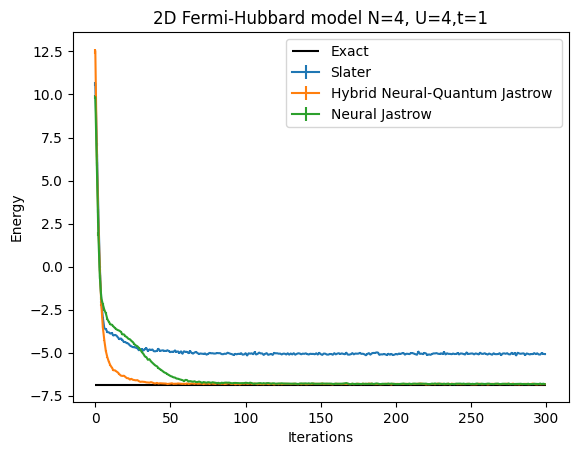

In [23]:
logged_data = (slater_log.data, nj_log.data, bf_log.data)
labels = ("Slater", "Hybrid Neural-Quantum Jastrow ", "Neural Jastrow")

from matplotlib import pyplot as plt

for data, label in zip(logged_data, labels):
    plt.errorbar(
        data["Energy"].iters,
        data["Energy"].Mean.real,
        yerr=data["Energy"].Sigma,
        label=label,
    )

plt.hlines([E_gs], xmin=0, xmax=300, color="black", label="Exact")
plt.title('2D Fermi-Hubbard model N=4, U=4,t=1')
plt.xlabel("Iterations")
plt.ylabel("Energy")
plt.legend()